(np)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`NumPy <single: NumPy>`

```{index} single: Python; NumPy
```

```{epigraph}
"Let's be clear: the work of science has nothing whatever to do with consensus.  Consensus is the business of politics. Science, on the contrary, requires only one investigator who happens to be right, which means that he or she has results that are verifiable by reference to the real world. In science consensus is irrelevant. What is relevant is reproducible results." -- Michael Crichton
```

Anaconda-യിലുള്ളവ കൂടാതെ, ഈ lecture-ന് താഴെ കൊടുത്തിരിക്കുന്ന libraries ആവശ്യമായിവരുന്നു:

In [1]:
!pip install quantecon

## Overview

[NumPy](https://en.wikipedia.org/wiki/NumPy) എന്നത്, numerical programming-നുള്ള ഒരു first-rate library ആണ്.

* Academia, finance, industry എന്നിവയിൽ വ്യാപകമായി ഉപയോഗിക്കപ്പെടുന്നു.
* Mature ആയതും, fast ആയതും, stable ആയതും, തുടർച്ചയായി development നടക്കുന്നതും ആണ്.

മുൻപത്തെ lectures-ൽ NumPy ഉൾപ്പെടുന്ന കുറച്ച് code നമ്മൾ already കണ്ടിട്ടുണ്ട്.

ഈ lecture-ൽ, നമുക്ക് 

1. NumPy arrays-നെക്കുറിച്ചും
1. NumPy provide ചെയ്യുന്ന അടിസ്ഥാന array processing operations-നെക്കുറിച്ചും

കൂടുതൽ systematic ആയ ഒരു discussion തുടങ്ങാം.

(ഒരു alternative reference-ന്, [the official NumPy documentation](https://numpy.org/doc/stable/reference/) കാണുക.)

താഴെ കൊടുത്തിരിക്കുന്ന imports നമുക്ക് ഉപയോഗിക്കാം.

In [2]:
import numpy as np
import random
import quantecon as qe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

(numpy_array)=
## NumPy Arrays

```{index} single: NumPy; Arrays
```

NumPy പരിഹരിക്കുന്ന അടിസ്ഥാന പ്രശ്നം fast array processing ആണ്.

NumPy define ചെയ്യുന്ന ഏറ്റവും പ്രധാനപ്പെട്ട structure, ഔപചാരികമായി [numpy.ndarray](https://numpy.org/doc/stable/reference/arrays.ndarray.html) എന്ന് വിളിക്കുന്ന ഒരു array data type ആണ്.

NumPy arrays, scientific Python ecosystem-ന്റെ വളരെ വലിയൊരു ഭാഗത്തിന് power നൽകുന്നു.

### Basics

Zeros മാത്രം അടങ്ങിയ ഒരു NumPy array create ചെയ്യാൻ നമുക്ക് [np.zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html#numpy.zeros) ഉപയോഗിക്കാം.

In [3]:
a = np.zeros(3)
a

array([0., 0., 0.])

In [4]:
type(a)

numpy.ndarray

NumPy arrays, native Python lists പോലെതന്നെയാണ്, പക്ഷേ ഇവിടെ

* Data *homogeneous ആയിരിക്കണം* (എല്ലാ elements-ഉം ഒരേ type-ൽ ആയിരിക്കണം).
* ഈ types, NumPy provide ചെയ്യുന്ന [data types](https://numpy.org/doc/stable/reference/arrays.dtypes.html) (`dtypes`) ഇൽ ഒന്നായിരിക്കണം.

ഈ dtypes-ൽ ഏറ്റവും പ്രധാനപ്പെട്ടവ:

* float64: 64 bit floating-point number
* int64: 64 bit integer
* bool:  8 bit True or False

Complex numbers, unsigned integers എന്നിവയെ represent ചെയ്യാൻ വേണ്ടിയുള്ള dtypes-ഉം ഉണ്ട്.

Modern machines-ൽ, arrays-ന്റെ default dtype `float64` ആണ്.

In [5]:
a = np.zeros(3)
type(a[0])

numpy.float64

Integers ഉപയോഗിക്കണമെങ്കിൽ താഴെ കൊടുത്തിരിക്കുന്ന രീതിയിൽ specify ചെയ്യാം:

In [6]:
a = np.zeros(3, dtype=int)
type(a[0])

numpy.int64

(numpy_shape_dim)=
### Shape and Dimension

```{index} single: NumPy; Arrays (Shape and Dimension)
```

താഴെ കൊടുത്തിരിക്കുന്ന assignment നോക്കാം:

In [7]:
z = np.zeros(10)

ഇവിടെ `z` ഒരു **flat** array ആണ് --- row vector-ഉം അല്ല column vector-ഉം അല്ല.

In [8]:
z.shape

(10,)

ഇവിടെ shape tuple-ന് ഒരു element മാത്രമേ ഉള്ളൂ, അതാണ് array-ന്റെ length (ഒരു element മാത്രമുള്ള tuples ഒരു comma-യിൽ അവസാനിക്കും).

ഇതിന് ഒരു additional dimension കൊടുക്കാൻ, നമുക്ക് `shape` attribute മാറ്റാം:

In [9]:
z.shape = (10, 1)   # Convert flat array to column vector (two-dimensional)
z

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [10]:
z = np.zeros(4)     # Flat array
z.shape = (2, 2)    # Two-dimensional array
z

array([[0., 0.],
       [0., 0.]])

അവസാനത്തെ case-ൽ, 2x2 array ഉണ്ടാക്കാൻ, `z = np.zeros((2, 2))` എന്ന രീതിയിൽ `zeros()` function-ന് ഒരു tuple pass ചെയ്യാനും കഴിയും.



(creating_arrays)=
### Creating Arrays

```{index} single: NumPy; Arrays (Creating)
```

നമ്മൾ കണ്ടതുപോലെ, `np.zeros` function zeros-ന്റെ ഒരു array create ചെയ്യുന്നു.

`np.ones` എന്ത് create ചെയ്യുമെന്ന് നിങ്ങൾക്ക് ഊഹിക്കാൻ കഴിയും.

ഇതുമായി ബന്ധപ്പെട്ടതാണ് `np.empty`, ഇത് memory-ൽ arrays create ചെയ്യുന്നു, അവ പിന്നീട് data ഉപയോഗിച്ച് populate ചെയ്യാം:

In [11]:
z = np.empty(3)
z

array([0., 0., 0.])

ഇവിടെ കാണുന്ന numbers garbage values ആണ്.

(Python 3 contiguous 64 bit memory pieces allocate ചെയ്യുന്നു, ആ memory slots-ലെ നിലവിലുള്ള content, `float64` values ആയി interpret ചെയ്യപ്പെടുന്നു)

Evenly spaced numbers-ന്റെ ഒരു grid set ചെയ്യാൻ `np.linspace` ഉപയോഗിക്കുക:

In [12]:
z = np.linspace(2, 4, 5)  # From 2 to 4, with 5 elements

ഒരു identity matrix create ചെയ്യാൻ `np.identity` അല്ലെങ്കിൽ `np.eye` ഉപയോഗിക്കുക:

In [13]:
z = np.identity(2)
z

array([[1., 0.],
       [0., 1.]])

കൂടാതെ, `np.array` ഉപയോഗിച്ച് Python lists, tuples, etc. നിന്നും NumPy arrays create ചെയ്യാം:

In [14]:
z = np.array([10, 20])                 # ndarray from Python list
z

array([10, 20])

In [15]:
type(z)

numpy.ndarray

In [16]:
z = np.array((10, 20), dtype=float)    # Here 'float' is equivalent to 'np.float64'
z

array([10., 20.])

In [17]:
z = np.array([[1, 2], [3, 4]])         # 2D array from a list of lists
z

array([[1, 2],
       [3, 4]])

`np.asarray` കൂടി കാണുക, ഇത് സമാനമായ ഒരു function perform ചെയ്യുന്നു, പക്ഷേ ഇത് already ഒരു NumPy array-ൽ ഉള്ള data-യുടെ വേറൊരു copy ഉണ്ടാക്കുന്നില്ല.

Numeric data അടങ്ങിയ ഒരു text file-ൽ നിന്നും array data read ചെയ്യാൻ `np.loadtxt` ഉപയോഗിക്കുക --- details-ന് [the documentation](https://numpy.org/doc/stable/reference/routines.io.html) കാണുക.



### Array Indexing

```{index} single: NumPy; Arrays (Indexing)
```

ഒരു flat array-ന്, indexing Python sequences-ന്റേത് പോലെതന്നെയാണ്:

In [18]:
z = np.linspace(1, 2, 5)
z

array([1.  , 1.25, 1.5 , 1.75, 2.  ])

In [19]:
z[0]

np.float64(1.0)

In [20]:
z[0:2]  # Two elements, starting at element 0

array([1.  , 1.25])

In [21]:
z[-1]

np.float64(2.0)

2D arrays-ന്, index syntax താഴെ കാണാം:

In [22]:
z = np.array([[1, 2], [3, 4]])
z

array([[1, 2],
       [3, 4]])

In [23]:
z[0, 0]

np.int64(1)

In [24]:
z[0, 1]

np.int64(2)

ഇങ്ങനെ തുടരാം.

Columns-ഉം rows-ഉം താഴെ കൊടുത്തിരിക്കുന്ന രീതിയിൽ extract ചെയ്യാം:

In [25]:
z[0, :]

array([1, 2])

In [26]:
z[:, 1]

array([2, 4])

Integers-ന്റെ NumPy arrays-ഉം elements extract ചെയ്യാൻ ഉപയോഗിക്കാം:

In [27]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [28]:
indices = np.array((0, 2, 3))
z[indices]

array([2. , 3. , 3.5])

അവസാനമായി, `dtype bool` ഉള്ള ഒരു array-യും elements extract ചെയ്യാൻ ഉപയോഗിക്കാം:

In [29]:
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [30]:
d = np.array([0, 1, 1, 0, 0], dtype=bool)
d

array([False,  True,  True, False, False])

In [31]:
z[d]

array([2.5, 3. ])

ഇത് എന്തുകൊണ്ട് useful ആണെന്ന് താഴെ നമുക്ക് കാണാം.

ഒരു side note: slice notation ഉപയോഗിച്ച് ഒരു array-യിലെ എല്ലാ elements-ഉം ഒരു number-ന് സമമായി set ചെയ്യാം:

In [32]:
z = np.empty(3)
z

array([2. , 3. , 3.5])

In [33]:
z[:] = 42
z

array([42., 42., 42.])

### Array Methods

```{index} single: NumPy; Arrays (Methods)
```

Arrays-ന് useful methods ഉണ്ട്, അവയെല്ലാം carefully optimize ചെയ്തിരിക്കുന്നു:

In [34]:
a = np.array((4, 3, 2, 1))
a

array([4, 3, 2, 1])

In [35]:
a.sort()              # Sorts a in place
a

array([1, 2, 3, 4])

In [36]:
a.sum()               # Sum

np.int64(10)

In [37]:
a.mean()              # Mean

np.float64(2.5)

In [38]:
a.max()               # Max

np.int64(4)

In [39]:
a.argmax()            # Returns the index of the maximal element

np.int64(3)

In [40]:
a.cumsum()            # Cumulative sum of the elements of a

array([ 1,  3,  6, 10])

In [41]:
a.cumprod()           # Cumulative product of the elements of a

array([ 1,  2,  6, 24])

In [42]:
a.var()               # Variance

np.float64(1.25)

In [43]:
a.std()               # Standard deviation

np.float64(1.118033988749895)

In [44]:
a.shape = (2, 2)
a.T                   # Equivalent to a.transpose()

array([[1, 3],
       [2, 4]])

അറിഞ്ഞിരിക്കേണ്ട മറ്റൊരു method ആണ് `searchsorted()`.

`z` ഒരു nondecreasing array ആണെങ്കിൽ, `z.searchsorted(a)`, `z`-ലെ `>= a` ആയ ആദ്യത്തെ element-ന്റെ index return ചെയ്യുന്നു:

In [45]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [46]:
z.searchsorted(2.2)

np.int64(1)

## Arithmetic Operations

```{index} single: NumPy; Arithmetic Operations
```

`+`, `-`, `*`, `/`, `**` എന്നീ operators എല്ലാം arrays-ൽ *elementwise* ആയാണ് work ചെയ്യുന്നത്:

In [47]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
a + b

array([ 6,  8, 10, 12])

In [48]:
a * b

array([ 5, 12, 21, 32])

താഴെ കൊടുത്തിരിക്കുന്ന രീതിയിൽ ഓരോ element-ഇനും ഒരു scalar നമുക്ക് ചേർക്കാം:

In [49]:
a + 10

array([11, 12, 13, 14])

Scalar multiplication സമാനമാണ്:

In [50]:
a * 10

array([10, 20, 30, 40])

Two-dimensional arrays-ഉം അതേ general rules തന്നെ പിന്തുടരുന്നു:

In [51]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A + B

array([[2., 2.],
       [2., 2.]])

In [52]:
A + 10

array([[11., 11.],
       [11., 11.]])

In [53]:
A * B

array([[1., 1.],
       [1., 1.]])

(numpy_matrix_multiplication)=
In particular, `A * B` matrix product അല്ല, ഇത് ഒരു element-wise product ആണ്.


## Matrix Multiplication

```{index} single: NumPy; Matrix Multiplication
```

```{index} single: NumPy; Matrix Multiplication
```

താഴെ കൊടുത്തിരിക്കുന്ന രീതിയിൽ matrix multiplication-ന് നമ്മൾ `@` symbol ഉപയോഗിക്കുന്നു:

In [54]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A @ B

array([[2., 2.],
       [2., 2.]])

Flat arrays-ഉമായി ഈ syntax work ചെയ്യുന്നു --- നിങ്ങൾക്ക് എന്താണ് വേണ്ടത് എന്നതിനെക്കുറിച്ച് NumPy ഒരു educated guess ഉണ്ടാക്കുന്നു:

In [55]:
A @ (0, 1)

array([1., 1.])

നമ്മൾ post-multiply ചെയ്യുന്നതിനാൽ, tuple ഒരു column vector ആയാണ് treat ചെയ്യപ്പെടുന്നത്.



(broadcasting)=
## Broadcasting

```{index} single: NumPy; Broadcasting
```

(ഈ section, [Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html) provide ചെയ്യുന്ന broadcasting-നെക്കുറിച്ചുള്ള excellent ആയ ഒരു discussion extend ചെയ്യുന്നു.)

```{note}
Broadcasting എന്നത്, NumPy-യുടെ വളരെ പ്രധാനപ്പെട്ട ഒരു aspect ആണ്. അതേസമയം, advanced broadcasting താരതമ്യേന complex ആണ്, താഴെയുള്ള ചില details ആദ്യതവണ വായിക്കുമ്പോൾ വേഗത്തിൽ കടന്നുപോകാം.
```

Element-wise operations-ൽ, arrays-ന് ഒരേ shape ഇല്ലാതിരിക്കാം.
 
ഇത് സംഭവിക്കുമ്പോൾ, സാധ്യമാകുന്നിടത്തെല്ലാം NumPy automatically arrays-നെ ഒരേ shape-ലേക്ക് expand ചെയ്യും.

NumPy-യിലെ ഈ useful ആയ (പക്ഷേ ചിലപ്പോൾ confusing ആയ) feature-നെ **broadcasting** എന്ന് വിളിക്കുന്നു.

Broadcasting-ന്റെ value എന്നത്:

* `for` loops ഒഴിവാക്കാം, ഇത് numerical code fast ആയി run ചെയ്യാൻ സഹായിക്കുന്നു, കൂടാതെ
* Arrays-ന്റെ ചില dimensions memory-ൽ actual ആയി create ചെയ്യാതെതന്നെ, ആ arrays-ൽ operations implement ചെയ്യാൻ broadcasting നമ്മളെ അനുവദിക്കുന്നു, arrays വലുതായിരിക്കുമ്പോൾ ഇത് important ആണ്.

For example, `a` ഒരു $3 \times 3$ array ആണെന്ന് കരുതുക (`a -> (3, 3)`), `b` ആകട്ടെ മൂന്ന് elements ഉള്ള ഒരു flat array ആണ് (`b -> (3,)`).

ഇവ ചേർത്ത് add ചെയ്യുമ്പോൾ, NumPy automatically `b -> (3,)`-നെ `b -> (3, 3)` ആയി expand ചെയ്യും.

Element-wise addition, ഒരു $3 \times 3$ array-ൽ result ചെയ്യും:

In [56]:
a = np.array(
        [[1, 2, 3], 
         [4, 5, 6], 
         [7, 8, 9]])
b = np.array([3, 6, 9])

a + b

array([[ 4,  8, 12],
       [ 7, 11, 15],
       [10, 14, 18]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation താഴെ കാണാം:

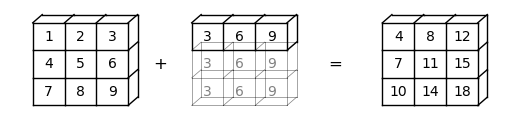

In [57]:
# Adapted and modified based on the code in the book written by Jake VanderPlas (see https://jakevdp.github.io/PythonDataScienceHandbook/06.00-figure-code.html#Broadcasting)
# Originally from astroML: see https://www.astroml.org/book_figures/appendix/fig_broadcast_visual.html


def draw_cube(ax, xy, size, depth=0.4,
              edges=None, label=None, label_kwargs=None, **kwargs):
    """draw and label a cube.  edges is a list of numbers between
    1 and 12, specifying which of the 12 cube edges to draw"""
    if edges is None:
        edges = range(1, 13)

    x, y = xy

    if 1 in edges:
        ax.plot([x, x + size],
                [y + size, y + size], **kwargs)
    if 2 in edges:
        ax.plot([x + size, x + size],
                [y, y + size], **kwargs)
    if 3 in edges:
        ax.plot([x, x + size],
                [y, y], **kwargs)
    if 4 in edges:
        ax.plot([x, x],
                [y, y + size], **kwargs)

    if 5 in edges:
        ax.plot([x, x + depth],
                [y + size, y + depth + size], **kwargs)
    if 6 in edges:
        ax.plot([x + size, x + size + depth],
                [y + size, y + depth + size], **kwargs)
    if 7 in edges:
        ax.plot([x + size, x + size + depth],
                [y, y + depth], **kwargs)
    if 8 in edges:
        ax.plot([x, x + depth],
                [y, y + depth], **kwargs)

    if 9 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth + size, y + depth + size], **kwargs)
    if 10 in edges:
        ax.plot([x + depth + size, x + depth + size],
                [y + depth, y + depth + size], **kwargs)
    if 11 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth, y + depth], **kwargs)
    if 12 in edges:
        ax.plot([x + depth, x + depth],
                [y + depth, y + depth + size], **kwargs)

    if label:
        if label_kwargs is None:
            label_kwargs = {}
        ax.text(x + 0.5 * size, y + 0.5 * size, label,
                ha='center', va='center', **label_kwargs)

solid = dict(c='black', ls='-', lw=1,
             label_kwargs=dict(color='k'))
dotted = dict(c='black', ls='-', lw=0.5, alpha=0.5,
              label_kwargs=dict(color='gray'))
depth = 0.3

# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '12', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '15', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '14', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

`b -> (3, 1)` ആണെങ്കിലോ?

ഈ case-ൽ, NumPy automatically `b -> (3, 1)`-നെ `b -> (3, 3)` ആയി expand ചെയ്യും.

Element-wise addition, അപ്പോൾ ഒരു $3 \times 3$ matrix-ൽ result ചെയ്യും:

In [58]:
b.shape = (3, 1)

a + b

array([[ 4,  5,  6],
       [10, 11, 12],
       [16, 17, 18]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation താഴെ കാണാം:

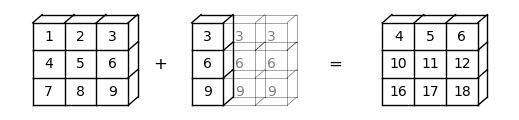

In [59]:
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '6', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '9', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '5', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '6', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '16', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '17', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');


ചില cases-ൽ, രണ്ട് operands-ഉം expand ചെയ്യപ്പെടും.

നമുക്ക് `a -> (3,)`-ഉം `b -> (3, 1)`-ഉം ഉള്ളപ്പോൾ, `a`, `a -> (3, 3)` ആയി expand ചെയ്യപ്പെടും, `b`-യാകട്ടെ `b -> (3, 3)` ആയി expand ചെയ്യപ്പെടും.

ഈ case-ൽ, element-wise addition, ഒരു $3 \times 3$ matrix-ൽ result ചെയ്യും:

In [60]:
a = np.array([3, 6, 9])
b = np.array([2, 3, 4])
b.shape = (3, 1)

a + b

array([[ 5,  8, 11],
       [ 6,  9, 12],
       [ 7, 10, 13]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation താഴെ കാണാം:

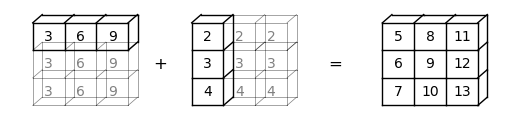

In [61]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (1, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '2', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '3', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '4', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '5', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '11', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '6', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '9', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '10', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '13', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

Broadcasting വളരെ useful ആണെങ്കിലും, ചിലപ്പോൾ ഇത് confusing ആയി തോന്നിയേക്കാം.

For example, `a -> (3, 2)`-ഉം `b -> (3,)`-ഉം add ചെയ്യാൻ ശ്രമിക്കാം.

In [62]:
a = np.array(
      [[1, 2],
       [4, 5],
       [7, 8]])
b = np.array([3, 6, 9])

a + b

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

Operands-നെ ഒരുമിച്ച് broadcast ചെയ്യാൻ കഴിഞ്ഞില്ല എന്ന് `ValueError` നമ്മോട് പറയുന്നു.


ഈ broadcasting എന്തുകൊണ്ട് execute ചെയ്യാൻ കഴിയില്ല എന്ന് കാണിക്കുന്ന ഒരു visual representation താഴെ കാണാം:

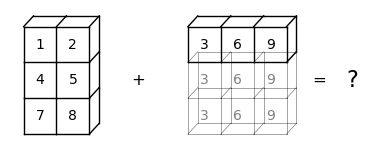

In [63]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(3, 1.3), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 7, 10], '5', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10], '8', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)


ax.text(4.5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10, 7.0, '=', size=12, ha='center', va='center')
ax.text(11, 7.0, '?', size=16, ha='center', va='center');

Arrays-നെ ഒരേ size-ലേക്ക് expand ചെയ്യാൻ NumPy-ക്ക് കഴിയില്ല എന്ന് നമുക്ക് കാണാം.

കാരണം, `b`-നെ `b -> (3,)` എന്നതിൽ നിന്നും `b -> (3, 3)` ആയി expand ചെയ്യുമ്പോൾ, `b`-നെ `a -> (3, 2)`-ഉമായി match ചെയ്യാൻ NumPy-ക്ക് കഴിയുന്നില്ല.

നമ്മൾ higher dimensions-ലേക്ക് പോകുമ്പോൾ കാര്യങ്ങൾ കൂടുതൽ tricky ആയി മാറും.

നമ്മെ സഹായിക്കാൻ, താഴെ കൊടുത്തിരിക്കുന്ന rules-ന്റെ list നമുക്ക് ഉപയോഗിക്കാം:

* *Step 1:* രണ്ട് arrays-ന്റെയും dimensions match ചെയ്യാത്തപ്പോൾ, കുറച്ച് dimensions ഉള്ളതിനെ, നിലവിലുള്ള dimensions-ന്റെ ഇടതുവശത്ത് dimension(s) ചേർത്ത് NumPy expand ചെയ്യും.
    - For example, `a -> (3, 3)`-ഉം `b -> (3,)`-ഉം ആണെങ്കിൽ, broadcasting ഇടതുവശത്ത് ഒരു dimension ചേർത്ത് `b -> (1, 3)` ആക്കും;
    - `a -> (2, 2, 2)`-ഉം `b -> (2, 2)`-ഉം ആണെങ്കിൽ, broadcasting ഇടതുവശത്ത് ഒരു dimension ചേർത്ത് `b -> (1, 2, 2)` ആക്കും;
    - `a -> (3, 2, 2)`-ഉം `b -> (2,)`-ഉം ആണെങ്കിൽ, broadcasting ഇടതുവശത്ത് രണ്ട് dimensions ചേർത്ത് `b -> (1, 1, 2)` ആക്കും (ഇത് *Step 1* രണ്ട് തവണ കടന്നുപോകുന്നതായും കാണാം).


* *Step 2:* രണ്ട് arrays-ന്റെയും dimension ഒരേപോലെയാണെങ്കിലും shapes വ്യത്യസ്തമാണെങ്കിൽ, shape index 1 ആയിരിക്കുന്ന dimensions expand ചെയ്യാൻ NumPy ശ്രമിക്കും.
    - For example, `a -> (1, 3)`-ഉം `b -> (3, 1)`-ഉം ആണെങ്കിൽ, broadcasting `a`-യിലും `b`-യിലും shape 1 ഉള്ള dimensions expand ചെയ്ത് `a -> (3, 3)`-ഉം `b -> (3, 3)`-ഉം ആക്കും;
    - `a -> (2, 2, 2)`-ഉം `b -> (1, 2, 2)`-ഉം ആണെങ്കിൽ, broadcasting `b`-യുടെ ആദ്യത്തെ dimension expand ചെയ്ത് `b -> (2, 2, 2)` ആക്കും;
    - `a -> (3, 2, 2)`-ഉം `b -> (1, 1, 2)`-ഉം ആണെങ്കിൽ, broadcasting shape 1 ഉള്ള എല്ലാ dimensions-ഇലും `b`-യെ expand ചെയ്ത് `b -> (3, 2, 2)` ആക്കും.

* *Step 3:* Step 1-ഉം 2-ഉം കഴിഞ്ഞ്, രണ്ട് arrays-ഉം ഇപ്പോഴും match ചെയ്യുന്നില്ലെങ്കിൽ, ഒരു `ValueError` raise ചെയ്യപ്പെടും. For example, `a -> (2, 2, 3)`-ഉം `b -> (2, 2)`-ഉം ആണെന്ന് കരുതുക
    - *Step 1* പ്രകാരം, `b`, `b -> (1, 2, 2)` ആയി expand ചെയ്യപ്പെടും;
    - *Step 2* പ്രകാരം, `b`, `b -> (2, 2, 2)` ആയി expand ചെയ്യപ്പെടും;
    - ആദ്യത്തെ രണ്ട് steps-ന് ശേഷവും ഇവ പരസ്പരം match ചെയ്യുന്നില്ല എന്ന് നമുക്ക് കാണാം. അതിനാൽ, ഒരു `ValueError` raise ചെയ്യപ്പെടും.



## Mutability and Copying Arrays

NumPy arrays, Python lists പോലെതന്നെ mutable data types ആണ്.

അതായത്, initialization-ന് ശേഷം memory-ൽ അവയുടെ contents alter ചെയ്യാൻ (mutate ചെയ്യാൻ) കഴിയും.

ഇത് convenient ആണ്, പക്ഷേ Python-ന്റെ naming and reference model-ഉമായി combine ചെയ്യുമ്പോൾ, ഇത് NumPy beginners-ന് mistakes-ലേക്ക് നയിച്ചേക്കാം.

ഈ section-ൽ നമുക്ക് ചില key issues നോക്കാം.


### Mutability

Mutability-യുടെ examples നമ്മൾ മുകളിൽ already കണ്ടിട്ടുണ്ട്.

ഒരു NumPy array-യുടെ mutation-ന്റെ മറ്റൊരു example താഴെ കാണാം:

In [64]:
a = np.array([42, 44])
a

array([42, 44])

In [65]:
a[-1] = 0  # Change last element to 0
a

array([42,  0])

Mutability, താഴെ കൊടുത്തിരിക്കുന്ന behavior-ലേക്ക് നയിക്കുന്നു (ഇത് MATLAB programmers-ന് shocking ആയി തോന്നിയേക്കാം...)

In [66]:
rng = np.random.default_rng()
a = rng.standard_normal(3)
a

array([ 0.93766324,  1.16909539, -1.0058808 ])

In [67]:
b = a
b[0] = 0.0
a

array([ 0.        ,  1.16909539, -1.0058808 ])

`b`-നെ മാറ്റുന്നതിലൂടെ നമ്മൾ `a`-യെ മാറ്റി എന്നതാണ് ഇവിടെ സംഭവിച്ചത്.

`b` എന്ന name, `a`-യുമായി bind ചെയ്യപ്പെട്ടിരിക്കുന്നു, അത് ആ array-യിലേക്കുള്ള മറ്റൊരു reference മാത്രമായി മാറുന്നു (Python assignment model കൂടുതൽ വിശദമായി {doc}`later in the course <python_advanced_features>`-ൽ describe ചെയ്തിട്ടുണ്ട്).

അതിനാൽ, ആ array-യിൽ changes വരുത്താൻ ഇതിന് തുല്യമായ rights ഉണ്ട്.

ഇത് വാസ്തവത്തിൽ ഏറ്റവും sensible ആയ default behavior ആണ്!

ഇതിനർത്ഥം, copies ഉണ്ടാക്കുന്നതിന് പകരം, data-യിലേക്കുള്ള pointers മാത്രമാണ് നമ്മൾ pass ചെയ്യുന്നത് എന്നാണ്.

Copies ഉണ്ടാക്കുന്നത്, speed-ന്റെയും memory-യുടെയും കാര്യത്തിൽ expensive ആണ്.

### Making Copies

ആവശ്യമുള്ളപ്പോൾ `b`-യെ `a`-യുടെ ഒരു independent copy ആക്കുന്നത് തീർച്ചയായും സാധ്യമാണ്.

`np.copy` ഉപയോഗിച്ച് ഇത് ചെയ്യാം:

In [68]:
a = rng.standard_normal(3)
a

array([ 0.46894609,  0.90095768, -0.50732009])

In [69]:
b = np.copy(a)
b

array([ 0.46894609,  0.90095768, -0.50732009])

ഇനി `b` ഒരു independent copy ആണ് (ഇതിനെ *deep copy* എന്ന് വിളിക്കുന്നു):

In [70]:
b[:] = 1
b

array([1., 1., 1.])

In [71]:
a

array([ 0.46894609,  0.90095768, -0.50732009])

`b`-യിലെ change, `a`-യെ affect ചെയ്തിട്ടില്ല എന്ന് ശ്രദ്ധിക്കുക.




## Additional Features

NumPy-യുടെ മറ്റ് ചില useful features നമുക്ക് നോക്കാം.


### Universal Functions

```{index} single: NumPy; Vectorized Functions
```

`log`, `exp`, `sin`, etc. പോലുള്ള standard functions-ന്റെ versions, arrays-ൽ *element-wise* ആയി work ചെയ്യുന്ന രീതിയിൽ NumPy provide ചെയ്യുന്നു:

In [72]:
z = np.array([1, 2, 3])
np.sin(z)

array([0.84147098, 0.90929743, 0.14112001])

ഇത് താഴെ കൊടുത്തിരിക്കുന്നത് പോലുള്ള explicit ആയ element-by-element loops-ന്റെ ആവശ്യം ഒഴിവാക്കുന്നു:

In [73]:
n = len(z)
y = np.empty(n)
for i in range(n):
    y[i] = np.sin(z[i])

Arrays-ൽ ഇവ element-wise ആയി work ചെയ്യുന്നതിനാൽ, ഈ functions-നെ ചിലപ്പോൾ **vectorized functions** എന്ന് വിളിക്കുന്നു.

NumPy-speak-ൽ, ഇവയെ **ufuncs**, അഥവാ **universal functions** എന്നും വിളിക്കുന്നു.

മുകളിൽ നമ്മൾ കണ്ടതുപോലെ, സാധാരണ arithmetic operations-ഉം (`+`, `*`, etc.) element-wise ആയി work ചെയ്യുന്നു, ഇവയെ ufuncs-ഉമായി combine ചെയ്യുമ്പോൾ fast element-wise functions-ന്റെ വളരെ വലിയൊരു set ലഭിക്കുന്നു.

In [74]:
z

array([1, 2, 3])

In [75]:
(1 / np.sqrt(2 * np.pi)) * np.exp(- 0.5 * z**2)

array([0.24197072, 0.05399097, 0.00443185])

എല്ലാ user-defined functions-ഉം element-wise ആയി work ചെയ്യില്ല.

For example, താഴെ define ചെയ്തിരിക്കുന്ന `f` എന്ന function-ന് ഒരു NumPy array pass ചെയ്യുന്നത് ഒരു `ValueError`-ന് കാരണമാകുന്നു:

In [76]:
def f(x):
    return 1 if x > 0 else 0

NumPy function `np.where`, ഒരു vectorized alternative provide ചെയ്യുന്നു:

In [77]:
x = rng.standard_normal(4)
x

array([ 2.30271983, -0.29101322, -0.20403518, -1.40929778])

In [78]:
np.where(x > 0, 1, 0)  # Insert 1 if x > 0 true, otherwise 0

array([1, 0, 0, 0])

തന്നിരിക്കുന്ന ഒരു function vectorize ചെയ്യാൻ നിങ്ങൾക്ക് `np.vectorize`-ഉം ഉപയോഗിക്കാം:

In [79]:
f = np.vectorize(f)
f(x)                # Passing the same vector x as in the previous example

array([1, 0, 0, 0])

എന്നിരുന്നാലും, ഈ approach-ന്, കൂടുതൽ carefully crafted ആയ ഒരു vectorized function-ന് ഉള്ളത്ര speed എപ്പോഴും ലഭിക്കണമെന്നില്ല.

(പിന്നീട് നമുക്ക് കാണാം, JAX-ന്, `np.vectorize`-ന്റെ ഒരു powerful version ഉണ്ട്, അത് highly efficient ആയ code generate ചെയ്യാൻ കഴിയുന്നതും, മിക്ക സമയത്തും അങ്ങനെ ചെയ്യുന്നതും ആണ്.)


### Comparisons

```{index} single: NumPy; Comparisons
```

സാധാരണയായി, arrays-ലെ comparisons element-wise ആയാണ് ചെയ്യുന്നത്:

In [80]:
z = np.array([2, 3])
y = np.array([2, 3])
z == y

array([ True,  True])

In [81]:
y[0] = 5
z == y

array([False,  True])

In [82]:
z != y

array([ True, False])

`>`, `<`, `>=`, `<=` എന്നിവയ്ക്കും situation സമാനമാണ്.

Scalars-നെതിരെയും നമുക്ക് comparisons ചെയ്യാം:

In [83]:
z = np.linspace(0, 10, 5)
z

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [84]:
z > 3

array([False, False,  True,  True,  True])

*Conditional extraction*-ന് ഇത് പ്രത്യേകിച്ചും useful ആണ്:

In [85]:
b = z > 3
b

array([False, False,  True,  True,  True])

In [86]:
z[b]

array([ 5. ,  7.5, 10. ])

തീർച്ചയായും നമുക്ക് ഇത് ഒറ്റ step-ൽ perform ചെയ്യാം --- മിക്ക സമയത്തും നമ്മൾ ഇങ്ങനെയാണ് ചെയ്യുന്നത്:

In [87]:
z[z > 3]

array([ 5. ,  7.5, 10. ])

### Sub-packages

Scientific programming-മായി ബന്ധപ്പെട്ട additional functionality, NumPy അതിന്റെ sub-packages വഴി provide ചെയ്യുന്നു.

NumPy-യുടെ [random `Generator`](https://numpy.org/doc/stable/reference/random/generator.html#random-generator) ഉപയോഗിച്ച് random variables എങ്ങനെ generate ചെയ്യാം എന്ന് നമ്മൾ already കണ്ടിട്ടുണ്ട്.

In [88]:
z = rng.standard_normal(10000)  # Generate standard normals
y = rng.binomial(10, 0.5, size=1000)    # 1,000 draws from Bin(10, 0.5)
y.mean()

np.float64(5.045)

സാധാരണയായി ഉപയോഗിക്കുന്ന മറ്റൊരു subpackage ആണ് np.linalg:

In [89]:
A = np.array([[1, 2], [3, 4]])

np.linalg.det(A)           # Compute the determinant

np.float64(-2.0000000000000004)

In [90]:
np.linalg.inv(A)           # Compute the inverse

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

```{index} single: SciPy
```

```{index} single: Python; SciPy
```

NumPy-യുടെ മുകളിൽ build ചെയ്തിരിക്കുന്ന modules-ന്റെ ഒരു collection ആയ [SciPy](https://scipy.org/)-യിലും ഈ functionality-യുടെ ഭൂരിഭാഗവും ലഭ്യമാണ്.

SciPy versions നമുക്ക് {doc}`soon <scipy>` കൂടുതൽ വിശദമായി cover ചെയ്യാം.

NumPy-യിൽ ലഭ്യമായതിന്റെ ഒരു comprehensive list-ന് [this documentation](https://numpy.org/doc/stable/reference/routines.html) കാണുക.


### Implicit Multithreading 

[Previously](need_for_speed) multithreading വഴിയുള്ള parallelization എന്ന concept നമ്മൾ discuss ചെയ്തിരുന്നു.

NumPy, അതിന്റെ compiled code-ന്റെ ഭൂരിഭാഗത്തിലും multithreading implement ചെയ്യാൻ ശ്രമിക്കുന്നു.

ഇത് action-ൽ കാണാൻ ഒരു example നമുക്ക് നോക്കാം.

താഴെ കൊടുത്തിരിക്കുന്ന code, randomly generate ചെയ്ത ഒരു വലിയ എണ്ണം matrices-ന്റെ eigenvalues compute ചെയ്യുന്നു.

ഇത് run ചെയ്യാൻ കുറച്ച് seconds എടുക്കുന്നു.

In [91]:
n = 20
m = 1000
for i in range(n):
    X = rng.standard_normal((m, m))
    λ = np.linalg.eigvals(X)

ഇനി, ഈ code run ചെയ്യുമ്പോൾ, നമ്മുടെ machine-ലെ htop system monitor-ന്റെ output നമുക്ക് നോക്കാം:

```{figure} /_static/lecture_specific/parallelization/htop_parallel_npmat.png
:scale: 80
```

8 CPUs-ൽ 4 എണ്ണം full speed-ൽ run ചെയ്യുന്നത് നമുക്ക് കാണാം.

ഇത് സംഭവിക്കുന്നത്, NumPy-യുടെ `eigvals` routine, tasks-നെ neat ആയി split ചെയ്ത് വ്യത്യസ്ത threads-ലേക്ക് distribute ചെയ്യുന്നത് കൊണ്ടാണ്.





## Exercises


```{exercise-start}
:label: np_ex1
```

Consider the polynomial expression

```{math}
:label: np_polynom

p(x) = a_0 + a_1 x + a_2 x^2 + \cdots a_N x^N = \sum_{n=0}^N a_n x^n
```

{ref}`Earlier <pyess_ex2>`, you wrote a simple function `p(x, coeff)` to evaluate {eq}`np_polynom` without considering efficiency.

Now write a new function that does the same job, but uses NumPy arrays and array operations for its computations, rather than any form of Python loop.

(Such functionality is already implemented as `np.poly1d`, but for the sake of the exercise don't use this class)

```{hint}
:class: dropdown
Use `np.cumprod()`
```
```{exercise-end}
```

```{solution-start} np_ex1
:class: dropdown
```

This code does the job

In [92]:
def p(x, coef):
    X = np.ones_like(coef)
    X[1:] = x
    y = np.cumprod(X)   # y = [1, x, x**2,...]
    return coef @ y

Let's test it

In [93]:
x = 2
coef = np.linspace(2, 4, 3)
print(coef)
print(p(x, coef))
# For comparison
q = np.poly1d(np.flip(coef))
print(q(x))

[2. 3. 4.]
24.0
24.0


```{solution-end}
```


```{exercise-start}
:label: np_ex2
```

Let `q` be a NumPy array of length `n` with `q.sum() == 1`.

Suppose that `q` represents a [probability mass function](https://en.wikipedia.org/wiki/Probability_mass_function).

We wish to generate a discrete random variable $x$ such that $\mathbb P\{x = i\} = q_i$.

In other words, `x` takes values in `range(len(q))` and `x = i` with probability `q[i]`.

The standard (inverse transform) algorithm is as follows:

* Divide the unit interval $[0, 1]$ into $n$ subintervals $I_0, I_1, \ldots, I_{n-1}$ such that the length of $I_i$ is $q_i$.
* Draw a uniform random variable $U$ on $[0, 1]$ and return the $i$ such that $U \in I_i$.

The probability of drawing $i$ is the length of $I_i$, which is equal to $q_i$.

We can implement the algorithm as follows

In [94]:
from random import uniform

def sample(q):
    a = 0.0
    U = uniform(0, 1)
    for i in range(len(q)):
        if a < U <= a + q[i]:
            return i
        a = a + q[i]

If you can't see how this works, try thinking through the flow for a simple example, such as `q = [0.25, 0.75]`
It helps to sketch the intervals on paper.

Your exercise is to speed it up using NumPy, avoiding explicit loops

```{hint}
:class: dropdown

Use `np.searchsorted` and `np.cumsum`

```

If you can, implement the functionality as a class called `DiscreteRV`, where

* the data for an instance of the class is the vector of probabilities `q`
* the class has a `draw()` method, which returns one draw according to the algorithm described above

If you can, write the method so that `draw(k)` returns `k` draws from `q`.

```{exercise-end}
```

```{solution-start} np_ex2
:class: dropdown
```

Here's our first pass at a solution:

In [95]:
from numpy import cumsum

class DiscreteRV:
    """
    Generates an array of draws from a discrete random variable with vector of
    probabilities given by q.
    """

    def __init__(self, q, seed=None):
        """
        The argument q is a NumPy array, or array like, nonnegative and sums
        to 1.

        The argument seed sets the seed for the underlying random number
        generator; with the default seed=None, draws are not reproducible
        across runs.
        """
        self.q = q
        self.Q = cumsum(q)
        self.rng = np.random.default_rng(seed)

    def draw(self, k=1):
        """
        Returns k draws from q. For each such draw, the value i is returned
        with probability q[i].
        """
        return self.Q.searchsorted(self.rng.uniform(0, 1, size=k))

The logic is not obvious, but if you take your time and read it slowly,
you will understand.

There is a problem here, however.

Suppose that `q` is altered after an instance of `DiscreteRV` is
created, for example by

In [96]:
q = (0.1, 0.9)
d = DiscreteRV(q)
d.q = (0.5, 0.5)

The problem is that `Q` does not change accordingly, and `Q` is the
data used in the `draw` method.

To deal with this, one option is to compute `Q` every time the draw
method is called.

But this is inefficient relative to computing `Q` once-off.

A better option is to use descriptors.

A solution from the [quantecon
library](https://github.com/QuantEcon/QuantEcon.py/tree/main/quantecon)
using descriptors that behaves as we desire can be found
[here](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/discrete_rv.py).

```{solution-end}
```


```{exercise}
:label: np_ex3

Recall our {ref}`earlier discussion <oop_ex1>` of the empirical cumulative distribution function.

Your task is to

1. Make the `__call__` method more efficient using NumPy.
1. Add a method that plots the ECDF over $[a, b]$, where $a$ and $b$ are method parameters.
```

```{solution-start} np_ex3
:class: dropdown
```

An example solution is given below.

In essence, we've just taken [this code](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/ecdf.py)
from QuantEcon and added in a plot method

In [97]:
"""
Modifies ecdf.py from QuantEcon to add in a plot method

"""

class ECDF:
    """
    One-dimensional empirical distribution function given a vector of
    observations.

    Parameters
    ----------
    observations : array_like
        An array of observations

    Attributes
    ----------
    observations : array_like
        An array of observations

    """

    def __init__(self, observations):
        self.observations = np.asarray(observations)

    def __call__(self, x):
        """
        Evaluates the ecdf at x

        Parameters
        ----------
        x : scalar(float)
            The x at which the ecdf is evaluated

        Returns
        -------
        scalar(float)
            Fraction of the sample less than x

        """
        return np.mean(self.observations <= x)

    def plot(self, ax, a=None, b=None):
        """
        Plot the ecdf on the interval [a, b].

        Parameters
        ----------
        a : scalar(float), optional(default=None)
            Lower endpoint of the plot interval
        b : scalar(float), optional(default=None)
            Upper endpoint of the plot interval

        """

        # === choose reasonable interval if [a, b] not specified === #
        if a is None:
            a = self.observations.min() - self.observations.std()
        if b is None:
            b = self.observations.max() + self.observations.std()

        # === generate plot === #
        x_vals = np.linspace(a, b, num=100)
        f = np.vectorize(self.__call__)
        ax.plot(x_vals, f(x_vals))
        plt.show()

Here's an example of usage

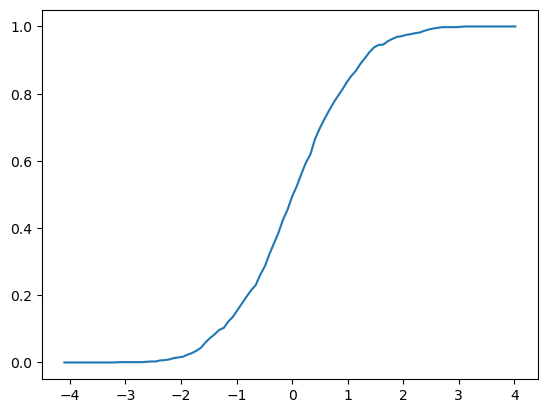

In [98]:
fig, ax = plt.subplots()
rng = np.random.default_rng()
X = rng.standard_normal(1000)
F = ECDF(X)
F.plot(ax)

```{solution-end}
```


```{exercise-start}
:label: np_ex4
```

Recall that [broadcasting](broadcasting) in NumPy can help us conduct element-wise operations on arrays with different number of dimensions without using `for` loops.

In this exercise, try to use `for` loops to replicate the result of the following broadcasting operations.

**Part 1**: Try to replicate this simple example using `for` loops and compare your results with the broadcasting operation below.

In [99]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)
A = x / y

Here is the output

In [100]:
print(A)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


**Part 2**: Move on to replicate the result of the following broadcasting operation. Meanwhile, compare the speeds of broadcasting and the `for` loop you implement.

For this part of the exercise you can use the `qe.Timer()` context manager from the `quantecon` library to time the execution. 

Let's make sure this library is installed.

In [101]:
!pip install quantecon

Now we can import the quantecon package.

In [102]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("Broadcasting operation"):
    B = x / y

Broadcasting operation: 0.0104 seconds elapsed


Here is the output

In [103]:
print(B)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

```{exercise-end}
```


```{solution-start} np_ex4
:class: dropdown
```

**Part 1 Solution**

In [104]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)

C = np.empty_like(x)
n = len(x)
for i in range(n):
    for j in range(n):
        C[i, j] = x[i, j] / y[j]

Compare the results to check your answer

In [105]:
print(C)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


You can also use `array_equal()` to check your answer

In [106]:
print(np.array_equal(A, C))

True


**Part 2 Solution**

In [107]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("For loop operation"):
    D = np.empty_like(x)
    d1, d2, d3 = x.shape
    for i in range(d1):
        for j in range(d2):
            for k in range(d3):
                D[i, j, k] = x[i, j, k] / y[k]

For loop operation: 3.9812 seconds elapsed


Note that the `for` loop takes much longer than the broadcasting operation.

Compare the results to check your answer

In [108]:
print(D)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

In [109]:
print(np.array_equal(B, D))

True


```{solution-end}
```